# Diabetes Risk Factor Analysis
### A reproducible workflow for describing clinical characteristics associated with diabetes

**Prepared by:** Cassie Duncan | **Version:** 1.0 | **Date:** 30Sep2026

**Contents:** 1. Purpose and Overview · 2. Setup/Environment · 3. Data Source/Provenance · 4. Data Loading ·
5. Data Validation · 6. Data Preparation · 7. Analysis · 8. Results · 9. Conclusions

## Purpose and Overview

**This section covers** what the notebook does, the questions it answers, and how to run it.

**Purpose:** This notebook describes how subject characteristics (glucose, BMI, age, blood pressure, family-history score, pregnancies, skinfold thickness and insulin) differ between subjects with and without diabetes, and which of them are associated with the outcome of diabetes.

**Intended users:** Data science teams at other clinical sites in our health system. The notebook is self-contained: follow the Markdown instructions and run it top to bottom.

**Research questions:**
1. How do key clinical characteristics differ between subjects with (`Outcome = 1`) and without (`Outcome = 0`) diabetes?
2. Is average glucose significantly different between subjects with and without diabetes?
3. Which characteristics stay associated with diabetes when considered together (adjusted odds ratios)?

**How to run this notebook:**
- Import and install all required libraries.
- Make sure `data/Example Dataset_Diabetes.csv` exists.
- Choose **Kernel → Restart Kernel and Run All Cells**. Always run cells in order.
- The notebook stops on purpose with an error message if the dataset can't be found or fails validation.

**Adapting to your own data:** Only the configuration identified later should need changes. The written interpretations describe the reference dataset and may not be applicable for new data.

## Setup / Environment

**This section covers** the libraries the notebook uses, a version check, the random seed, and the settings you may need to change.

This section imports all the libraries used in the notebook and prints their versions. If your versions are different from the ones in the README, your results might be slightly different.

A random seed is also set in this section. This makes anything random (like sampling) give the same result every time the notebook runs.

In [1]:
# import all the libraries in one place
import os
import sys
import platform
import hashlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# expected versions for what the notebook was built and tested with
expected_versions = {
    "pandas": "2.2.3",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2",
    "statsmodels": "0.15.0"
}
# versions actually installed for user running notebook
installed_versions = {
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "statsmodels": statsmodels.__version__
}

# display basic environment information
print("Python:", platform.python_version(), "(expected 3.13.15)")
print("Operating system:", platform.system(), platform.release())
print()

# verison check to report OK or a warning for each package
for package in expected_versions:
    installed = installed_versions[package]
    expected = expected_versions[package]
    if installed == expected:
        print(f"{package}: {installed}  OK")
    else:
        print(f"{package}: {installed}  WARNING - expected {expected}")

Python: 3.13.15 (expected 3.13.15)
Operating system: Linux 6.6.122+

pandas: 2.2.3  OK
numpy: 2.1.3  OK
scipy: 1.16.3  OK
matplotlib: 3.10.0  OK
seaborn: 0.13.2  OK
statsmodels: 0.15.0  OK


### Configuration
These are the only settings you should need to change if you use a different dataset (other than the provided reference dataset). These variables act as "constants" for the remainder of the notebook.


`SEED` controls every random step so results are the same every time.

In [2]:
# set random seed for anything random used in the notebook, such as bootstrapping
SEED = 78
np.random.seed(SEED)

# name of dataset used throughout the notebook
file_name = "Example Dataset_Diabetes.csv"

# what the dataset should look like
EXPECTED_COLUMNS = ["Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
                    "Insulin", "BMI", "Pedigree", "Age", "Outcome"]
EXPECTED_ROW_COUNT = 768
EXPECTED_OUTCOME_COUNTS = {0: 500, 1: 268}

# columns where 0 is impossible and means a value was not recorded
ZERO_IMPOSSIBLE = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI", "Age"]

# significance level for the statistical tests
ALPHA = 0.05

sns.set_theme(style="whitegrid")
print("Setup complete. Seed =", SEED)

Setup complete. Seed = 78


## Data Source / Provenance

**This section covers** where the dataset came from, who the subjects are, what each column means, and the dataset's role in this project.


- **File:** `Example Dataset_Diabetes.csv`
- **Original source:** Pima Indians Diabetes Database, from the National Institute of Diabetes
  and Digestive and Kidney Diseases (NIDDK). Public copies are on the UCI Machine Learning
  Repository and Kaggle.
- **Subjects:** 768 women of Pima Indian heritage, aged 21 or older, near Phoenix, Arizona.
- **Role in this project:** This is public example data used to build and test the workflow. Another site can swap in its own data if the columns are the same.

**Outcome variable:** `Outcome` (1 = diabetes, 0 = no diabetes)

**Predictor variables:**

| Column | Meaning | Units |
|---|---|---|
| Pregnancies | Number of pregnancies | count |
| Glucose | Plasma glucose 2 hours into an oral glucose tolerance test | mg/dL |
| D_BP | Diastolic blood pressure | mm Hg |
| Skin_Thickness | Triceps skinfold thickness | mm |
| Insulin | 2-hour serum insulin | µU/mL |
| BMI | Body mass index | kg/m² |
| Pedigree | Diabetes pedigree function (family history score) | none |
| Age | Age | years |

**Known issue:** In several measurement columns, a value of 0 is assumed to mean the measurement was not recorded. This is handled in later sections.

## Data Loading

**This section covers** reading the CSV file into a pandas DataFrame.

The original notebook used the path `/content/Example Dataset_Diabetes.csv`, which only works
in Google Colab. The notebook now looks for the file in two places:
1. the `data` folder
2. the same folder as the notebook (this also works in Colab if you upload the file to `/content`)

The `Example Dataset_Diabetes.csv` file should be added to the `data` folder before running.
If the file can't be found, the cell will stop and provide a helpful error message.

In [3]:
# locate the CSV file that contains the raw diabetes data

# check the data folder first, then the current working directory
if os.path.exists(os.path.join("data", file_name)):
    file_path = os.path.join("data", file_name)
elif os.path.exists(file_name):
    file_path = file_name
else:
    # if the file cannot be found in either location, raise a clear error
    raise FileNotFoundError("Could not find the dataset. Put '" + file_name +
                            "' in the data folder (see README).")

# load the CSV into a pandas DataFrame
df_raw = pd.read_csv(file_path)
print("Loaded file from:", file_path)

# display the first 5 rows of the dataset as a useful sanity check
df_raw.head()

Loaded file from: Example Dataset_Diabetes.csv


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Expected output (if using provided reference dataset):** 768 rows and 9 columns. The first row should read
`6, 148, 72, 35, 0, 33.6, 0.627, 50, 1`.

## Data Validation

**This section covers** automatic checks that the expected dataset was loaded correctly and also includes a count of the impossible zero values.

Each check prints `PASS` or `FAIL`. If any check fails, the notebook stops, so no results are produced from the wrong data.

**Note:** If you're using your own data (not the provided reference dataset), update `EXPECTED_ROW_COUNT` and `EXPECTED_OUTCOME_COUNTS` from the earlier section to match your data.

In [4]:
# function will print PASS or FAIL and stop the notebook if the check failed
def check(description, passed):
    if passed:
        print("PASS: ", description)
    else:
        print("FAIL: ", description)
        # stops function and gives a ValueError with a custom message
        raise ValueError("Validation failed: " + description)

# structure of output for each check
check("Column names and order match the expected schema",
      list(df_raw.columns) == EXPECTED_COLUMNS)
check(f"Row count is {EXPECTED_ROW_COUNT}", len(df_raw) == EXPECTED_ROW_COUNT)
check("All columns are numeric",
      all(pd.api.types.is_numeric_dtype(df_raw[c]) for c in df_raw.columns))

# all data validation checks to be run by the above function
check("No blank (NaN) cells", df_raw.isna().sum().sum() == 0)
check("No duplicate rows", df_raw.duplicated().sum() == 0)
check("Outcome contains only 0 and 1", set(df_raw["Outcome"].unique()) == {0, 1})
check("Outcome counts match expected",
      df_raw["Outcome"].value_counts().to_dict() == EXPECTED_OUTCOME_COUNTS)
check("No negative values", (df_raw < 0).sum().sum() == 0)
check("Age is between 18 and 100", df_raw["Age"].between(18, 100).all())
check("Glucose is below 300", (df_raw["Glucose"] < 300).all())
check("BMI is below 80", (df_raw["BMI"] < 80).all())

print("\nShape:", df_raw.shape)
print("\nAll validation checks passed.")
print("\nData types:")
print(df_raw.dtypes)

PASS:  Column names and order match the expected schema
PASS:  Row count is 768
PASS:  All columns are numeric
PASS:  No blank (NaN) cells
PASS:  No duplicate rows
PASS:  Outcome contains only 0 and 1
PASS:  Outcome counts match expected
PASS:  No negative values
PASS:  Age is between 18 and 100
PASS:  Glucose is below 300
PASS:  BMI is below 80

Shape: (768, 9)

All validation checks passed.

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object


### Checking for zeros
There are no blank cells, but several columns contain zeros that aren't possible for a living person (e.g., BMI or blood pressure of 0). These zeros likely represent missing or unrecorded values. In this section, these impossible zero values are counted for validation. The feature `Pregnancies` can reasonably contain a value of 0.

**Expected counts (if usisng the provided reference dataset):** Glucose 5, D_BP 35, Skin_Thickness 227, Insulin 374, BMI 11, Age 0.

In [5]:
# count how many zero values each column contains
zero_counts = (df_raw == 0).sum()

# calculate the percentage of zeros per column
zero_percent = ((df_raw == 0).mean() * 100).round(1)

# build a summary table of the zero values calculated above
zero_table = pd.DataFrame({"zeros_count": zero_counts, "pct_zeros": zero_percent})

# flag for which columns a zero value is impossible
zero_table["zero_impossible_value"] = zero_table.index.isin(ZERO_IMPOSSIBLE)

# output the table
zero_table

,zeros_count,pct_zeros,zero_impossible_value
Pregnancies,111,14.5,False
Glucose,5,0.7,True
D_BP,35,4.6,True
Skin_Thickness,227,29.6,True
Insulin,374,48.7,True
BMI,11,1.4,True
Pedigree,0,0.0,False
Age,0,0.0,True
Outcome,500,65.1,False


## Data Preparation

**This section covers** recoding the impossible zeros as missing values and creating the cleaned dataset used for all analysis.

**Decision:** In `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin` and `BMI`, the value 0 is replaced with `NaN` (missing). Leaving the values as zeros would lower the means and inflate the standard deviations.

**Potential Issues with Decision:** Each statistic will be based on a slightly different number of subjects. The `count` column in the descriptive tables shows how many.

**Why not impute values?** Imputing values adds assumptions. For a descriptive analysis, it's more transparent to leave them missing. pandas automatically skips `NaN` in calculations, such as for the mean.

The raw data (`df_raw`) is left untouched. All analysis uses the copy `df_clean`.

In [6]:
# make clean copy of the raw data
df_clean = df_raw.copy()

# replace impossible zeros with missing values (NaN)
df_clean[ZERO_IMPOSSIBLE] = df_clean[ZERO_IMPOSSIBLE].replace(0, np.nan)

# report how many missing values were introduced
print("Count of missing values after replacing zeros:")
print(df_clean.isna().sum())

# inspect 10 random subjects as subset of the cleaned data
# random_state makes it show the same rows every time
df_clean.sample(10, random_state=SEED)

Count of missing values after replacing zeros:
Pregnancies         0
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
Pedigree            0
Age                 0
Outcome             0
dtype: int64


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
533,6,91.0,NaN,NaN,NaN,29.8,0.501,31,0
62,5,44.0,62.0,NaN,NaN,25.0,0.587,36,0
421,2,94.0,68.0,18.0,76.0,26.0,0.561,21,0
751,1,121.0,78.0,39.0,74.0,39.0,0.261,28,0
577,2,118.0,80.0,NaN,NaN,42.9,0.693,21,1
64,7,114.0,66.0,NaN,NaN,32.8,0.258,42,1
622,6,183.0,94.0,NaN,NaN,40.8,1.461,45,0
498,7,195.0,70.0,33.0,145.0,25.1,0.163,55,1
732,2,174.0,88.0,37.0,120.0,44.5,0.646,24,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


## Analysis

**This section covers** how the dataset is written as a statistical/machine-learning problem, descriptive statistics, visualizations, the correlation matrix, two inferential tests with full assumption checks, and a seeded bootstrap.

### The dataset as a statistical and machine-learning problem

Our dataset is written as

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad n = 768, \qquad x_i \in \mathbb{R}^{8}, \qquad y_i \in \{0, 1\}
$$

where

- $\mathcal{D}$ is the full set of 768 records in `Example Dataset_Diabetes.csv`
- $i$ represents the index of an individual observation (row number for each subject), where $i = 1, 2, \ldots, 768$
- $x_i$ is the vector of $p = 8$ measurements for Subject $i$ (every column except `Outcome`)
- $y_i$ is Subject $i$'s `Outcome`: 0 = no diabetes (500 Subjects), 1 = diabetes (268 Subjects)

Because $y_i$ has only two values, this is a **binary classification** problem.

For one Subject:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D\_BP}_i \\
\text{Skin\_Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix},
\qquad
y_i = \text{Outcome}_i
$$

A classifier would learn a function

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0, 1\}
$$

that takes a Subject's 8 measurements and predicts whether `Outcome` is 0 or 1. The hat on
$\hat{f}$ means it's an *estimate* learned from data, not the true relationship.

**Note:** This notebook doesn't train a prediction model. It only uses descriptive statistics and statistical tests. This section shows how the data would be set up for a model later.

### Descriptive Statistics

**This section covers** summary statistics for each measurement, overall and separately for Subjects with and without diabetes, and how to read them.

**Statistics used:**

For a variable such as glucose measured on $n$ Subjects (Subjects with a missing value are
skipped, so $n$ differs by variable):

- **Mean** (average):
  $$\bar{x}_{\text{Glucose}} = \frac{1}{n}\sum_{i=1}^{n}\text{Glucose}_i$$
- **Standard deviation** (typical distance from the mean; $n-1$ is what pandas uses by default):
  $$s_{\text{Glucose}} = \sqrt{\frac{\sum_{i=1}^{n}(\text{Glucose}_i - \bar{x}_{\text{Glucose}})^2}{n-1}}$$
- **Median**: the middle value when Subjects are sorted. This is not affected by extreme values.
- **IQR (interquartile range):** 75th percentile − 25th percentile or the spread of the middle 50% of subjects.
- **Skewness**: 0 means symmetric, while a positive value means a long tail of high values.

**Why calculate both mean/SD and median/IQR?** Some variables (`Insulin`, `Pedigree`, `Age`,
`Pregnancies`) have a few very high values. The mean gets pulled toward those values, while the
median doesn't. When the mean is noticeably above the median, the median is the better
"typical" value.

In this notebook, the mean and standard deviation for each outcome group are calculated separately, so we can compare Subjects with and without diabetes.

In [7]:
# stats use clean dataset where zeros have already been replaced with NaN

# overall summary
print("Overall summary:")
display(df_clean.describe().round(2))

# mean and standard deviation for each outcome group
group_stats = df_clean.groupby("Outcome").agg(["mean", "std"]).round(2)
print("Mean and standard deviation by Outcome (0 = no diabetes, 1 = diabetes):")
display(group_stats.T)

Overall summary:


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.00,763.00,733.00,541.00,394.00,757.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,155.55,32.46,0.47,33.24,0.35
std,3.37,30.54,12.38,10.48,118.78,6.92,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Mean and standard deviation by Outcome (0 = no diabetes, 1 = diabetes):


Outcome                   0       1
Pregnancies    mean    3.30    4.87
               std     3.02    3.74
Glucose        mean  110.64  142.32
               std    24.78   29.60
D_BP           mean   70.88   75.32
               std    12.16   12.30
Skin_Thickness mean   27.24   33.00
               std    10.03   10.33
Insulin        mean  130.29  206.85
               std   102.48  132.70
BMI            mean   30.86   35.41
               std     6.56    6.61
Pedigree       mean    0.43    0.55
               std     0.30    0.37
Age            mean   31.19   37.07
               std    11.67   10.97

**What this shows:**
- Mean glucose should be about 110.6 mg/dL for Subjects without diabetes and about
  142.3 mg/dL for Subjects with diabetes, so Subjects with diabetes are about 32 mg/dL higher
  on average.
- Mean BMI and age are also higher in the diabetes group.
- The standard deviation for glucose is about 25–30 mg/dL in both groups. This is relatively large, so some Subjects without diabetes still have high glucose.
- Insulin has a large standard deviation compared to its mean, which means the values are very
  spread out.

Your output should match if you're using the provided reference dataset.

### Visualizations

**This section covers** histograms of glucose and BMI (one variable at a time) and two bivariate plots, including a boxplot of glucose by outcome and a scatterplot of glucose vs. BMI.

#### Histograms
These show how glucose and BMI are distributed through the shape (symmetric or skewed), the center, and any extreme values.

`df_clean` is used, so the zeros have already been replaced with NaN and will not be shown on the visualizations.


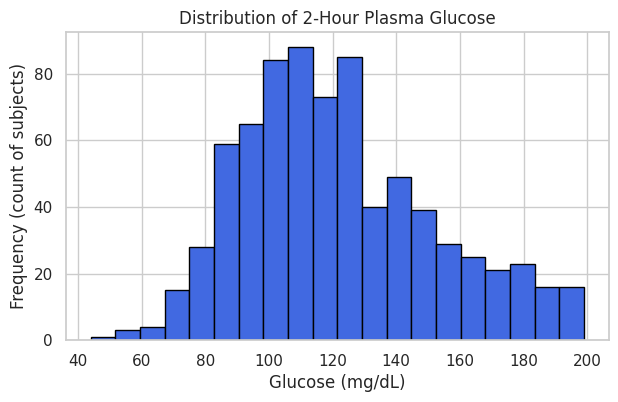

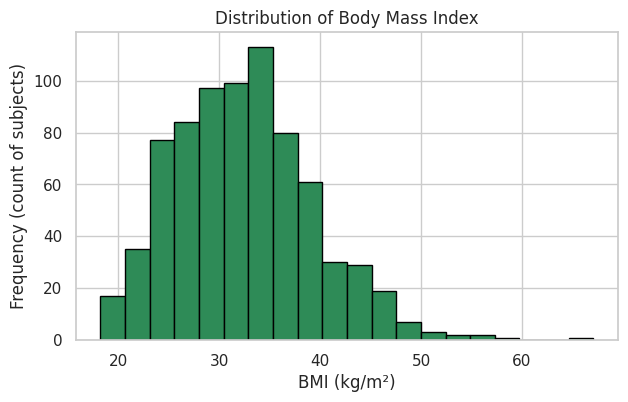

In [8]:
# plot the distribution of 2-hour plasma glucose

# create new figure and set size
plt.figure(figsize=(7, 4))

# plot a histogram of the Glucose variable
plt.hist(df_clean["Glucose"].dropna(), bins=20, color="royalblue", edgecolor="black")
# add a descriptive title and axis labels so the plot is self‑explanatory
plt.title("Distribution of 2-Hour Plasma Glucose")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Frequency (count of subjects)")

# render the figure in the notebook
plt.show()


# plot the distribution of body mass index (BMI)

# create aew figure so the BMI histogram appears in its own plot window
plt.figure(figsize=(7, 4))

# plot histogram of the BMI column (again dropping missing values first)
# the color scheme is different to visually distinguish the two plots
plt.hist(df_clean["BMI"].dropna(), bins=20, color="seagreen", edgecolor="black")
# title and axis labels for the BMI plot
plt.title("Distribution of Body Mass Index")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Frequency (count of subjects)")

# render the second figure in the notebook
plt.show()


**Interpretation:** Most glucose values are between about 80 and 160 mg/dL, with a tail of higher values, so it's slightly right-skewed. Most BMI values are between 25 and 40, and many subjects are obese at a BMI of 30 or more.

#### Bivariate Plot 1: Boxplot of glucose by diabetes outcome
A boxplot is a good way to compare a continuous variable (glucose) across
two groups (outcome 0 and 1). The box is the middle 50%, the line is the median, the white dot is the mean, and points beyond the whiskers are outliers.

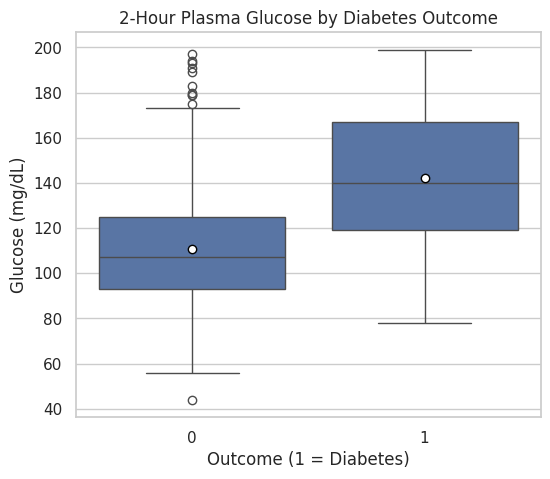

In [9]:
# box‑plot of 2‑Hour Plasma Glucose split by diabetes outcome

# create new figure
plt.figure(figsize=(6, 5))

# build the box‑plot with Seaborn
sns.boxplot(
    data=df_clean, x="Outcome", y="Glucose",
    legend=False, showmeans=True,
    # customise the appearance of the mean marker with:
    # a hollow circle (marker "o")
    # white fill with a black edge, so it stands out against the box
    meanprops={"marker": "o",
               "markerfacecolor": "white",
               "markeredgecolor": "black"}
)
# add a clear, descriptive title and axis labels
plt.title("2-Hour Plasma Glucose by Diabetes Outcome")
plt.xlabel("Outcome (1 = Diabetes)")
plt.ylabel("Glucose (mg/dL)")

# render the plot in the notebook
plt.show()

**Interpretation:** The glucose box for Subjects with diabetes sits higher than the box for
Subjects without diabetes. The median is around 140 mg/dL for the diabetes group and around 107 mg/dL for the no-diabetes group. There's still overlap between roughly 110 and 150 mg/dL, so
glucose alone doesn't perfectly separate the groups, but it's clearly higher in the diabetes group.

#### Bivariate plot 2: Scatterplot of glucose vs. BMI, colored by outcome
A scatterplot shows the relationship between two numeric variables. Points are colored by Outcome to see how subjects with diabetes compare to those without.

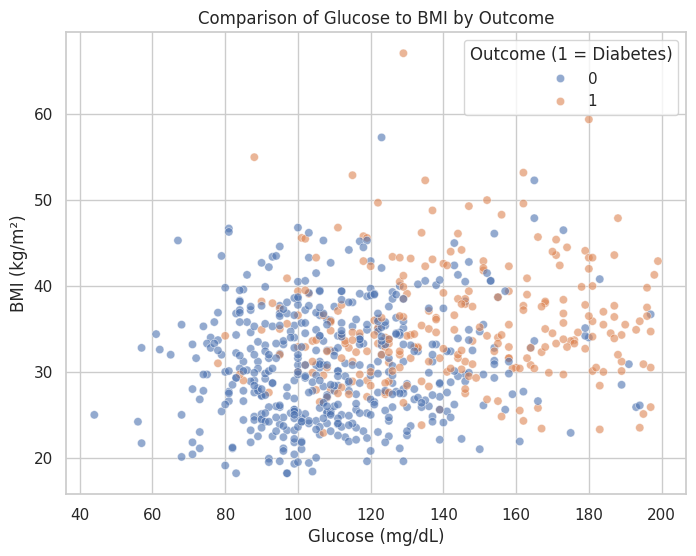

In [10]:
# ccatter plot of Glucose vs. Body Mass Index (BMI), colored by outcome

# create new figure
plt.figure(figsize=(8, 6))

# plot each subject as a point
sns.scatterplot(data=df_clean, x="Glucose", y="BMI", hue="Outcome", alpha=0.6)
# add a clear, descriptive title and axis labels
plt.title("Comparison of Glucose to BMI by Outcome")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI (kg/m²)")
# give the legend a title that explains the color coding
plt.legend(title="Outcome (1 = Diabetes)")

# render the plot in the notebook
plt.show()

**Interpretation:** The points don't form a clear line, so if glucose and BMI are related, the relationship is weak. However, most of the diabetes points (Outcome = 1) are concentrated in the upper right, where both glucose and BMI are high, while the lower-left corner, low glucose and low BMI, mostly don't have diabetes. This indicates a potential relationship with having both high glucose and high BMI to having diabetes.

### Correlation matrix and heatmap

**This section covers** the correlation between every pair of numeric variables, why Spearman's method was chosen, and which relationships appear the most important.

**Method: Spearman's rank correlation**

$$
\rho = 1 - \frac{6\sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

where $d_i$ is the difference between Subject $i$'s rank on one variable and their rank on the
other, and $n$ is the number of Subjects with both values.

**Why Spearman's instead of Pearson's Rank**
- Several variables are skewed with outliers (`Insulin`, `Pedigree`, `Age`, `Pregnancies`).
  Pearson's correlation is sensitive to outliers, while Spearman's uses ranks, so it isn't.
- Spearman's detects any consistently increasing or decreasing relationship, not just a straight line.
- `Pregnancies` is a count and `Outcome` is 0/1 and rank-based correlation handles these reasonably.

Correlation values go from -1 to 1:
- close to 1 = strong positive relationship
- close to 0 = little or no relationship
- close to -1 = strong negative relationship

Missing values are skipped for each pair of variables.

See the Supplementary Materials for more information on correlations.

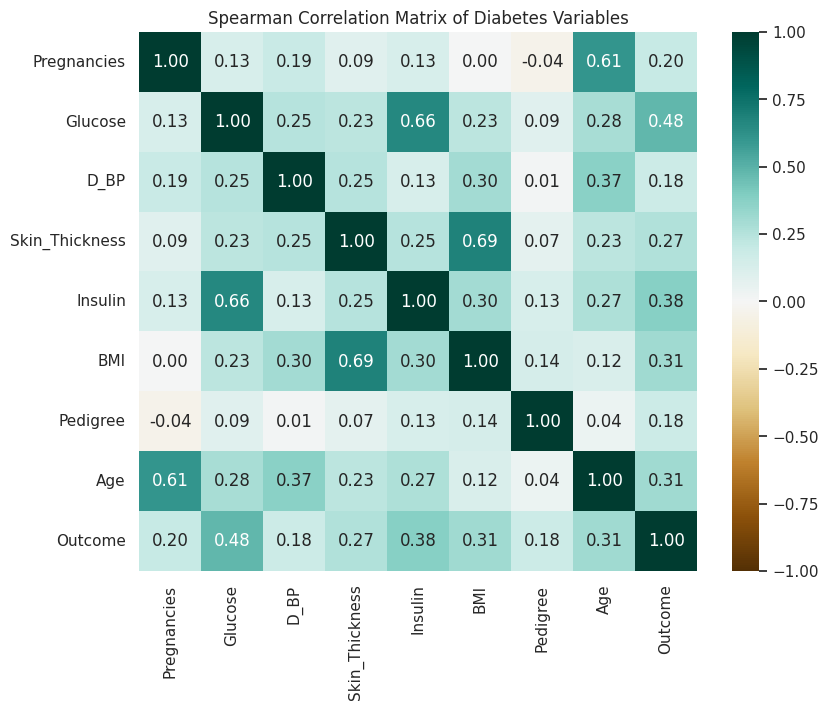

In [11]:
#  compute and visualize a Spearman's rank correlation matrix

# calculate pairwise Spearman correlations between all numeric columns
corr_matrix = df_clean.corr(method="spearman")

# create a new figure for the heat‑map
plt.figure(figsize=(9, 7))

# draw the correlation matrix as a heat‑map
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="BrBG", vmin=-1, vmax=1)
# add a descriptive title
plt.title("Spearman Correlation Matrix of Diabetes Variables")

# render the heat-map in the notebook
plt.show()

**Interpretation:**
- **Glucose and Outcome** have the strongest correlation (moderate and positive, about 0.5). Higher glucose is associated with having diabetes.
- **Insulin and Outcome** have the next strongest correlation (positive, about 0.4).
- **BMI and Age** have weaker positive correlations with Outcome (about 0.3). Higher BMI and older age are associated with diabetes.
- Among the predictors, **`Pregnancies` and `Age`** are correlated (older women have had more
  pregnancies), **`BMI` and `Skin_Thickness`** are correlated (both measure body fat), and
  **`Glucose` and `Insulin`** are correlated (insulin rises in response to glucose).
- **D_BP and Pedigree** have the weakest correlations with Outcome (0.18), while **Pregnancies** has a weak correlation as well (0.20).
- No strong negative correlations appear in this dataset.
- Correlation describes association in this sample only. It doesn't show causation and doesn't
  account for other variables.

### Inferential Analysis 1: Comparing mean glucose between outcome groups (t-test)

**This section covers** the full process for testing whether mean glucose differs between subjects with and without diabetes: question, hypotheses, validate assumptions, choose test, result, effect size, and interpretation.

**Step 1 – Question:** Is mean 2-hour glucose different in Subjects with diabetes compared to
Subjects without diabetes?

**Step 2 – Hypotheses:** (two-sided, $\alpha = 0.05$)

$$
H_0: \mu_{\text{Glucose}\,|\,\text{Diabetes}} = \mu_{\text{Glucose}\,|\,\text{No diabetes}}
\qquad
H_1: \mu_{\text{Glucose}\,|\,\text{Diabetes}} \neq \mu_{\text{Glucose}\,|\,\text{No diabetes}}
$$

**Step 3 – Assumptions of a two-sample t-test (and how they are checked):**
1. The two groups are independent. Check that each Subject is in exactly one group.
2. Glucose is continuous.
3. Glucose is approximately normal within each group **or** the samples are large. This can be checked through histograms, Q-Q plots, skewness, or through the Shapiro–Wilk test. Both groups have well over 30 Subjects, so the Central Limit Theorem makes the test robust to moderate skew.
4. Equal variances (Student's t-test only). Validate using Levene's test. If variances differ, use Welch's t-test, which doesn't need this assumption.

**Step 4 – Test statistic** (Welch's version, which is used if Levene's test is significant):

$$
t = \frac{\bar{x}_1 - \bar{x}_0}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}}
$$

where $\bar{x}_1, s_1, n_1$ are the mean, SD and size of the diabetes group and
$\bar{x}_0, s_0, n_0$ the same for the no-diabetes group.

**Step 5 – Effect size:** A p-value says whether a difference exists, not how big it is.
Cohen's $d$ expresses the difference in SD units (0.2 small, 0.5 medium, 0.8 large):

$$
d = \frac{\bar{x}_1 - \bar{x}_0}{s_{\text{pooled}}}, \qquad
s_{\text{pooled}} = \sqrt{\frac{(n_1-1)s_1^2 + (n_0-1)s_0^2}{n_1 + n_0 - 2}}
$$

This notebook version uses cleaned data (so there are no impossible zero values), checks the assumptions, and picks the test based on the results (rather than using Student's t-test without checking equal variances).

See the Supplementary Materials for more information on two-sample t tests.

In [12]:
# verify the assumption of independence between the two outcome groups

# split the cleaned DataFrame into two subsets
# one for having diabetes and one for not having diabetes
no_diabetes = df_clean[df_clean["Outcome"] == 0]
diabetes = df_clean[df_clean["Outcome"] == 1]

# extract the Glucose measurements for each group, dropping any missing values
glucose_no = no_diabetes["Glucose"].dropna()
glucose_yes = diabetes["Glucose"].dropna()

# compute the sample sizes for each group and print a quick descriptive summary
n0 = len(glucose_no)
n1 = len(glucose_yes)
print("No diabetes: n =", n0, " mean =", round(glucose_no.mean(), 1),
      " SD =", round(glucose_no.std(), 1))
print("Diabetes:    n =", n1, " mean =", round(glucose_yes.mean(), 1),
      " SD =", round(glucose_yes.std(), 1))

# the printed output lets you quickly verify that the two groups have
# reasonable (and different) sample sizes, means, and standard deviations,
# which is a prerequisite before proceeding to a formal two‑sample test
# (e.g., Welch’s t‑test) that assumes the groups are independent

No diabetes: n = 497  mean = 110.6  SD = 24.8
Diabetes:    n = 266  mean = 142.3  SD = 29.6


In [13]:
# check the assumption of normality of the Glucose variable for each outcome group

# this is assessed both through visual/quantitative skewness
# and through the Shapiro‑Wilk test

# run the Shapiro‑Wilk test on each group
shapiro_no = stats.shapiro(glucose_no)
shapiro_yes = stats.shapiro(glucose_yes)

# compute and print the skewness for each group
print("Skewness, no diabetes:", round(glucose_no.skew(), 2))
print("Skewness, diabetes:   ", round(glucose_yes.skew(), 2))
print()

# print the Shapiro‑Wilk p‑values
print("Shapiro-Wilk p-value, no diabetes:", (shapiro_no.pvalue))
print("Shapiro-Wilk p-value, diabetes:   ", round(shapiro_yes.pvalue, 4))

# values > 0.05 suggest the distribution is not significantly different from normal

Skewness, no diabetes: 0.65
Skewness, diabetes:    0.09

Shapiro-Wilk p-value, no diabetes: 1.3180222532869116e-07
Shapiro-Wilk p-value, diabetes:    0.0001


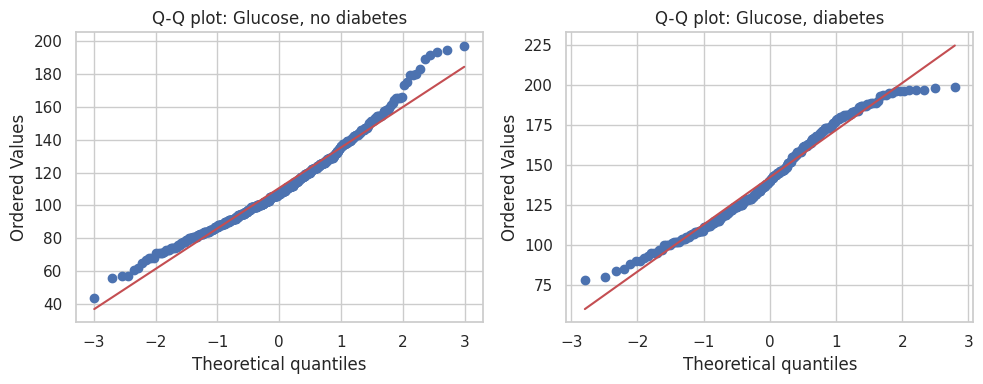

In [14]:
# continue checking normality assumption of Glucose
# using Q-Q plots (points near the line = close to normal)

# create a figure wide enough to hold two side‑by‑side subplots
plt.figure(figsize=(10, 4))

# create subplot of subjects without diabetes (Outcome = 0)
plt.subplot(1, 2, 1)
stats.probplot(glucose_no, dist="norm", plot=plt)
plt.title("Q-Q plot: Glucose, no diabetes")

# create subplot of subjects with diabetes (Outcome = 1)
plt.subplot(1, 2, 2)
stats.probplot(glucose_yes, dist="norm", plot=plt)
plt.title("Q-Q plot: Glucose, diabetes")

# adjust layout and display the figure
plt.tight_layout()
plt.show()

In [15]:
# check assumption of equal variances through Levene's test

# run Levene's test on the glucose values of the two groups
levene_result = stats.levene(glucose_no, glucose_yes)

# print the test statistic and p‑value for the user to inspect
print("Levene's test statistic:", round(levene_result.statistic, 3))
print("Levene's test p-value:  ", (levene_result.pvalue))


# decide which version of the two‑sample t‑test to apply
# based on the p‑value and the pre‑defined significance level `ALPHA`
if levene_result.pvalue < ALPHA:
    # tell downstream code that variances differ
    equal_var = False
    test_name = "Welch's t-test"
    print("The variances differ. Use Welch's t-test.")
else:
    # variances can be treated as equal
    equal_var = True
    test_name = "Student's t-test"
    print("No evidence the variances differ. Student's t-test is acceptable.")

Levene's test statistic: 23.212
Levene's test p-value:   1.751837138668383e-06
The variances differ. Use Welch's t-test.


**Interpretation of the assumption checks:** The Shapiro–Wilk p-values are below 0.001, which is normal for samples of several hundred Subjects (the test picks up even tiny departures from normality). The Q-Q plots show a mild upward bend at the high end, matching the right skew seen in the histogram. Because both groups have hundreds of Subjects, the t-test is still appropriate.
Levene's test is significant (p-value is below 0.001), so the code switches to Welch's t-test automatically.

In [16]:
#  Run the two‑sample t‑test for the difference in mean Glucose
#  diabetes group – no‑diabetes group

# run the appropriate independent‑samples t‑test
t_result = stats.ttest_ind(glucose_yes, glucose_no, equal_var=equal_var)

# extract the statistic and the p‑value
t_stat = t_result.statistic
t_p = t_result.pvalue

# compute the observed difference in sample means
mean_diff = glucose_yes.mean() - glucose_no.mean()

# obtain a 95 % confidence interval for that mean difference
ci = t_result.confidence_interval(confidence_level=0.95)
ci_low = ci.low
ci_high = ci.high

# print a concise summary
print(test_name)
print("Difference in means:", round(mean_diff, 1), "mg/dL")
print("95% CI for the difference:", round(ci_low, 1), "to", round(ci_high, 1))
print("t statistic:", round(t_stat, 2))
print("p-value:", t_p)

Welch's t-test
Difference in means: 31.7 mg/dL
95% CI for the difference: 27.5 to 35.9
t statistic: 14.88
p-value: 2.8439261927745043e-41


In [17]:
#  calculate an effect‑size using Cohen's d for the glucose difference
#  and make a formal statistical decision based on the previously‑computed
#  t‑test p‑value (t_p) and the significance level (ALPHA)

# sample variances of the two groups
var_no = glucose_no.var()
var_yes = glucose_yes.var()

# pooled standard deviation
pooled_sd = np.sqrt(((n1 - 1) * var_yes + (n0 - 1) * var_no) / (n1 + n0 - 2))

# compute Cohen's d
# a positive d indicates higher glucose in the diabetes group
cohens_d = mean_diff / pooled_sd

# report the effect size rounded to two decimal places
print("Cohen's d:", round(cohens_d, 2))

print()

# make a binary hypothesis‑testing decision using the t‑test p‑value

# if the p‑value is smaller than the pre‑specified ALPHA value,
# reject the null hypothesis of equal means, otherwise, fail to reject
if t_p < ALPHA:
    print("Decision: p <", ALPHA, "so we reject H0.")
else:
    print("Decision: p >=", ALPHA, "so we fail to reject H0.")

Cohen's d: 1.19

Decision: p < 0.05 so we reject H0.


**Final Interpretation:** Subjects with diabetes have a mean 2-hour glucose about
**32 mg/dL higher** than Subjects without diabetes. The 95% CI (roughly 28–36 mg/dL) excludes zero, and the p-value is far below 0.001, so we reject $H_0$: the difference is very unlikely to be due to chance.
Cohen's d, 1.19, is a **large** effect. The difference
is both statistically and clinically meaningful. This is an unadjusted comparison of two groups that does not account for age, BMI, or other factors.

### Inferential Analysis 2: Multivariable logistic regression

**This section covers** a model that looks at several Subject characteristics at the same time to see which ones are still associated with diabetes after adjusting for the others. It follows the full process: question, hypotheses, pre-fit assumption checks, model fitting, post-fit checks, effect sizes and interpretation.

**Step 1 – Question:** How does each characteristic relate to the odds of diabetes while holding the other characteristics constant?

**Why logistic regression?** The outcome is binary (0/1). Ordinary linear regression could predict values below 0 or above 1. Logistic regression models the log-odds of diabetes instead, which keeps predicted probabilities between 0 and 1.

**Predictors used ($p = 6$):** `Pregnancies`, `Glucose`, `D_BP`, `BMI`, `Pedigree`, `Age`.

**Predictors left out:** `Skin_Thickness` (about 30% missing) and `Insulin` (about 49% missing) as including them would cut the sample size from about 724 to about 390 subjects. They also largely overlap with BMI and Glucose.

**Missing data:** Complete-case analysis, so only Subjects with all six predictors recorded are used.

This model is used for inference (explaining associations), not prediction. It's fit on all complete cases. There's no training/test split and no prediction accuracy is reported.

**The model:** For Subject $i$, let $\pi_i = P(\text{Outcome}_i = 1 \mid x_i)$ be the probability
of diabetes. Then

$$
\log\!\left(\frac{\pi_i}{1 - \pi_i}\right)
= \beta_0 + \beta_1\,\text{Pregnancies}_i + \beta_2\,\text{Glucose}_i + \beta_3\,\text{D\_BP}_i
+ \beta_4\,\text{BMI}_i + \beta_5\,\text{Pedigree}_i + \beta_6\,\text{Age}_i
$$

where

- $\log\!\left(\frac{\pi_i}{1-\pi_i}\right)$ is the **log-odds** (logit) of diabetes for Subject $i$
- $\beta_0$ is the intercept
- $\beta_j$ is the change in log-odds for a 1-unit increase in predictor $j$, **holding the other
  five predictors constant**

**Odds ratios:** Exponentiating a coefficient gives an **adjusted odds ratio**:

$$
\text{OR}_j = e^{\beta_j},
\qquad
\text{OR}_j^{(k)} = e^{k\,\beta_j}
$$

$\text{OR}_j^{(k)}$ is the odds ratio for an increase of $k$ units, used to report clinically
meaningful steps. OR < 1 means lower odds.

**Step 2 – Hypotheses:** (α = 0.05)

*Overall model (likelihood-ratio test):*

$$
H_0: \beta_1 = \beta_2 = \cdots = \beta_6 = 0
\qquad
H_1: \text{at least one } \beta_j \neq 0
$$

$$
G = -2\left(\ell_0 - \ell_1\right) \sim \chi^2_{6}
$$

where $\ell_0$ is the log-likelihood of a model with only an intercept and $\ell_1$ is the
log-likelihood of the full model.

*Each predictor (Wald z-test):*

$$
H_0: \beta_j = 0 \;\;(\text{OR}_j = 1)
\qquad
H_1: \beta_j \neq 0,
\qquad
z_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

**Step 3 – Assumptions of logistic regression (and how and when to check):**
1. Outcome is binary. Check outcome only contains 0 and 1 before fitting.
2. Units of analysis are sampled independently (i.i.d.; identically, independently distributed). Check for one row per Subject and no repeated measures before fitting (verified here through study design).
3. Enough events per predictor (large sample size). Check for events per variable (EPV) ≥ 10 before fitting.
4. No severe multicollinearity. Check VIF < 5 for every predictor before fitting.
5. Continuous predictors have a linear relationship with the log-odds. Check using Box–Tidwell test before fitting.
6. Lack of strongly influential outliers. Check using cook's distance after fitting the model.
7. Model fits the data adequately. Check using Hosmer–Lemeshow goodness-of-fit test after fitting.

Logistic regression does not assume that predictors are normally distributed or that the outcome groups have equal variances.

**Formulas used to check assumptions:**

- **EPV** = (number of Subjects in the smaller outcome group) ÷ (number of predictors).
- **VIF** for predictor $j$: $\text{VIF}_j = \dfrac{1}{1 - R_j^2}$, where $R_j^2$ is how well the
  *other* predictors explain predictor $j$. VIF = 1 means no overlap. VIF > 5 is a common warning sign.
- **Box–Tidwell:** for each continuous predictor $x$, add the term $x \ln(x)$ to the model and test
  $H_0: \gamma = 0$ for its coefficient $\gamma$. A significant term suggests the relationship with
  the log-odds isn't linear. $\ln(x)$ needs $x > 0$, so `Pregnancies` (which can be 0) uses $x + 1$.
- **Cook's distance:** measures how much all the coefficients change if one Subject is removed.
  Common cut-off: $D_i > 4/n$.
- **Hosmer–Lemeshow:** sort Subjects into 10 groups by predicted probability, then compare observed
  and expected numbers of diabetes cases in each group:
  $$
  H = \sum_{g=1}^{10} \frac{(O_g - E_g)^2}{E_g\,(1 - E_g / n_g)} \sim \chi^2_{8}
  $$
  where $O_g$ is the observed number of cases in group $g$, $E_g$ is the sum of predicted
  probabilities in that group, and $n_g$ is the group size. A non-significant p-value
  (p ≥ 0.05) means no evidence of poor fit.
  
See the Supplementary Materials for more information on logistic regression.

In [18]:
# logistic‑regression preparation
# select predictors and keep only complete cases (no missing values)

# define the six variables that will be used as predictors in the model
logit_predictors = ["Pregnancies", "Glucose", "D_BP", "BMI", "Pedigree", "Age"]

# subset the cleaned data to keep only the predictor columns and Outcome
# then drop any rows that contain missing values (`NaN`) in any of those columns
# the resulting dataframe contains only complete cases
logit_data = df_clean[logit_predictors + ["Outcome"]].dropna()


# report how many subjects are available at each stage

# total number of rows after the zero‑to‑NaN cleaning step
print("Subjects in the cleaned data:", len(df_clean))
# number of rows that have non‑missing values for all six predictors plus Outcome
print("Complete cases used in the model:", len(logit_data))
# how many rows were dropped because at least one of the required variables was missing
print("Subjects excluded (missing values):", len(df_clean) - len(logit_data))
print()


# show the class distribution within the modelling dataset

# these counts let you see whether the outcome is balanced or imbalanced
# after filtering to complete cases
print("Diabetes (Outcome = 1):", (logit_data["Outcome"] == 1).sum())
print("No diabetes (Outcome = 0):", (logit_data["Outcome"] == 0).sum())

Subjects in the cleaned data: 768
Complete cases used in the model: 724
Subjects excluded (missing values): 44

Diabetes (Outcome = 1): 249
No diabetes (Outcome = 0): 475


In [19]:
# verify binary assumption
# that the target variable (Outcome) contains only the two
# allowed values 0 and 1

# convert NumPy array to a set of the distinct values that actually appear
# in the column after we have filtered for complete cases
if set(logit_data["Outcome"].unique()) == {0, 1}:
    # if the sets match, the outcome is properly binary
    print("PASS - Assumption 1: Outcome is binary (0/1)")
else:
    # any other situation (e.g., missing values, additional categories)
    # means the binary‑outcome assumption is violated
    print("FAIL - Assumption 1: Outcome is not binary")

PASS - Assumption 1: Outcome is binary (0/1)


In [20]:
# check the events‑per‑variable (EPV) assumption

# count how many subjects experienced the event (Outcome == 1)
events = (logit_data["Outcome"] == 1).sum()

# count how many subjects did not experience the event (Outcome == 0)
non_events = (logit_data["Outcome"] == 0).sum()

# for EPV, the size of the smaller outcome group is used
# because the rarer class drives the amount of information available
# for estimating the coefficients
smaller_group = min(events, non_events)

# compute EPV
# this tells us, on average, how many outcome events we have per predictor
epv = smaller_group / len(logit_predictors)

# report the EPV
print("Events per variable (EPV):", round(epv, 1))

# enforce the rule of thumb that EPV should be at least 10
# if it is, we consider the model adequately powered
# if not, a warning is given to reduce the number of predictors (or collect more data)
if epv >= 10:
    print("PASS - Assumption 3: EPV is at least 10")
else:
    print("FAIL - Assumption 3: EPV is below 10. Use fewer predictors.")

Events per variable (EPV): 41.5
PASS - Assumption 3: EPV is at least 10


In [21]:
# check assumption of multicollinearity using Variance Inflation Factors (VIF)
# high VIF values (commonly ≥ 5 or ≥ 10) indicate that a predictor is
# highly correlated with the other predictors,
# which can inflate standard errors and destabilize the model

# build the design matrix X that will be fed to the VIF calculator
X = sm.add_constant(logit_data[logit_predictors])
# extract the outcome variable
y = logit_data["Outcome"]

print("VIF:")
# compute VIF for each predictor (skip column 0, which is the intercept)
vif_values = []
for i in range(1, X.shape[1]):
    # variance_inflation_factor expects a NumPy array and the column index
    vif = variance_inflation_factor(X.values, i)
    vif_values.append(vif)
    # print the VIF
    print("  ", X.columns[i], ":", round(vif, 2))


# evaluate the multicollinearity assumption

# if all VIFs are below 5, the multicollinearity is considered to be
# non‑problematic and the assumption passes
if max(vif_values) < 5:
    print("PASS - Assumption 4: every VIF is below 5, no severe multicollinearity")
# if any VIF reaches 5 or higher, a warning is issued to
# consider removing or combining correlated predictors
else:
    print("WARNING - Assumption 4: at least one VIF is 5 or more")

VIF:
   Pregnancies : 1.46
   Glucose : 1.16
   D_BP : 1.24
   BMI : 1.16
   Pedigree : 1.04
   Age : 1.63
PASS - Assumption 4: every VIF is below 5, no severe multicollinearity


In [22]:
# check assumption of linearity with the log-odds (Box-Tidwell test)

# the Box‑Tidwell test adds an interaction term X·ln(X) for every predictor
# if the coefficient of that interaction is not significantly different
# from zero, the linearity assumption holds

# work on a copy so we don’t modify the original modelling dataframe
bt_data = logit_data.copy()
# prepare a list that will store the names of the new interaction terms
bt_terms = []

# loop over each predictor used in the logistic model
for column in logit_predictors:
    # create the transformed variable X·ln(X) required by Box‑Tidwell
    # for variables that can be zero, in this case just "Pregnancies", we add 1
    # because the natural logarithm of 0 is undefined
    if column == "Pregnancies":
        x = bt_data[column] + 1
    else:
        x = bt_data[column]
    # the interaction term is X multiplied by its log
    bt_data[column + "_xlnx"] = x * np.log(x)
    # keep track of the new column names
    bt_terms.append(column + "_xlnx")

# build the design matrix for the Box‑Tidwell model
# containing the original predictors and the X·ln(X) interaction terms,
# adding a constant column for the intercept
X_bt = sm.add_constant(bt_data[logit_predictors + bt_terms])

# fit a logistic regression model (Logit) using the expanded matrix
bt_model = sm.Logit(bt_data["Outcome"], X_bt).fit(disp=0)

# examine the p‑values of each interaction term
print("Box-Tidwell test (p-value for each x*ln(x) term):")
# will collect any terms that reject linearity
nonlinear = []
for term in bt_terms:
    # p‑value for the coefficient of the interaction
    p = bt_model.pvalues[term]
    print("  ", term, ": p =", round(p, 4))
    if p < ALPHA:
        nonlinear.append(term)

# summarize the result
if len(nonlinear) == 0:
    print("PASS - Assumption 5: no evidence of non-linearity with the log-odds")
else:
    print("WARNING - Assumption 5: possible non-linearity for", nonlinear)

Box-Tidwell test (p-value for each x*ln(x) term):
   Pregnancies_xlnx : p = 0.4569
   Glucose_xlnx : p = 0.2819
   D_BP_xlnx : p = 0.9886
   BMI_xlnx : p = 0.0901
   Pedigree_xlnx : p = 0.0097
   Age_xlnx : p = 0.0
WARNING - Assumption 5: possible non-linearity for ['Pedigree_xlnx', 'Age_xlnx']


**Interpretation of the pre-fit checks:**

- **Assumptions 1–2:** Verified by the structure of the data and the study design.
- **Assumption 3:** There are about 250 diabetes cases among the 724 complete cases, giving an EPV of 41.5, which is above 10.
- **Assumption 4:** Every VIF is well below 5, roughly 1–1.6. `Age` and `Pregnancies` have the highest VIFs because they're correlated (ρ is about 0.6), but the overlap isn't severe.
- **Assumption 5:** The Box‑Tidwell test adds an interaction term *X·ln(X)* for each predictor and tests whether its coefficient differs from zero. `Pregnancies`, `Glucose`, `D_BP`, and `BMI` all have p‑values > 0.05, so the linearity assumption is reasonable for these variables. However, `Pedigree` (p = 0.0097) and `Age` (p = 0.0000) are significant, indicating that the relationship between these predictors and the log‑odds of diabetes is not perfectly linear. The odds ratios reported for `Pedigree` and `Age` describe an average effect across the observed range. A later analysis could model these predictors more flexibly.

In [23]:
# fit the logistic‑regression model using StatsModels
logit_model = sm.Logit(y, X).fit(disp=0)

# generate nicely formatted table
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  724
Model:                          Logit   Df Residuals:                      717
Method:                           MLE   Df Model:                            6
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                  0.2780
Time:                        22:01:56   Log-Likelihood:                -336.43
converged:                       True   LL-Null:                       -465.97
Covariance Type:            nonrobust   LLR p-value:                 4.707e-53
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -8.9621      0.821    -10.918      0.000     -10.571      -7.353
Pregnancies     0.1179      0.033      3.527      0.000       0.052       0.183
Glucose         0.0352      0.004      9.763    

In [24]:
# overall goodness‑of‑fit test for the fitted logistic regression model
# use (Likelihood‑ratio test) and McFadden pseudo‑R²

# likelihood‑ratio statistic
lr_stat = logit_model.llr
# degrees of freedom for the test
lr_df = logit_model.df_model
# p‑value for the likelihood‑ratio test
lr_p = logit_model.llr_pvalue
# McFadden’s pseudo‑R²
mcfadden_r2 = logit_model.prsquared

# print a concise summary of the overall model test
print("Likelihood-ratio test: G =", round(lr_stat, 2), " df =", int(lr_df), " p =", lr_p)
print("McFadden pseudo R-squared:", round(mcfadden_r2, 3))
print()

# make formal decision based on the pre‑specified significance level (ALPHA)
if lr_p < ALPHA:
    # the null hypothesis is rejected
    # at least one predictor contributes significantly to the model
    print("Decision: p <", ALPHA, "so we reject H0. At least one predictor is associated with diabetes.")
else:
    # no evidence that the model improves over the intercept‑only model
    print("Decision: p >=", ALPHA, "so we fail to reject H0.")

Likelihood-ratio test: G = 259.08  df = 6  p = 4.707320634409122e-53
McFadden pseudo R-squared: 0.278

Decision: p < 0.05 so we reject H0. At least one predictor is associated with diabetes.


In [25]:
# identify influential observations (subjects) using Cook's distance

# statsmodels calculates Cook's distance from the same model fitted as a GLM
glm_model = sm.GLM(y, X, family=sm.families.Binomial()).fit()

# extract Cook's distance for every observation
cooks = glm_model.get_influence().cooks_distance[0]

# define a rule‑of‑thumb cut‑off for flagging influential point
# use common threshold of 4 / n
threshold = 4 / len(logit_data)

# create a mark for which subjects exceed the cut‑off
influential = cooks > threshold

# summarize the results
print("Cook's distance cut-off (4/n):", round(threshold, 4))
# number of subjects whose Cook's distance is above the threshold
print("Subjects above the cut-off:", influential.sum(), "of", len(logit_data))
# the largest Cook's distance observed
# useful to see how extreme the most influential point is
print("Largest Cook's distance:", round(cooks.max(), 4))

Cook's distance cut-off (4/n): 0.0055
Subjects above the cut-off: 42 of 724
Largest Cook's distance: 0.057


In [26]:
# Hosmer‑Lemeshow goodness‑of‑fit test for the logistic model
# to check whether the predicted probabilities from the model
# match the observed frequencies of the outcome across groups of subjects

# build a temporary dataframe
# stores the observed outcome and the model‑predicted probability for each subject
hl_data = pd.DataFrame()
hl_data["observed"] = y
hl_data["predicted"] = logit_model.predict(X)

# break the subjects into 10 groups based on their predicted probabilities
# create quantile‑based bins so each group contains roughly the same number of subjects
hl_data["group"] = pd.qcut(hl_data["predicted"], 10, labels=False, duplicates="drop")

# summarize observed and expected counts within each group
observed_cases = hl_data.groupby("group")["observed"].sum()
expected_cases = hl_data.groupby("group")["predicted"].sum()
group_size = hl_data.groupby("group")["observed"].count()

# compute the Hosmer‑Lemeshow chi‑square statistic
hl_stat = (((observed_cases - expected_cases) ** 2) /
           (expected_cases * (1 - expected_cases / group_size))).sum()

# set degrees of freedom
hl_df = len(group_size) - 2

# p‑value from the chi‑square survival function (upper tail)
hl_p = stats.chi2.sf(hl_stat, hl_df)

# assemble a nicely‑formatted table for composition of each group
hl_table = pd.DataFrame({"Subjects": group_size,
                         "observed cases": observed_cases,
                         "expected cases": expected_cases.round(1)})
print(hl_table)
print()

# report the test statistic, its df, and the p‑value
print("Hosmer-Lemeshow statistic:", round(hl_stat, 2), " df =", hl_df, " p =", round(hl_p, 4))

# if p ≥ α, PASS the goodness‑of‑fit assumption
if hl_p >= ALPHA:
    print("PASS - Assumption 7: no evidence of poor fit")
# if p < α, WARN that the model may be poorly calibrated
else:
    print("WARNING - Assumption 7: evidence of poor fit")

       Subjects  observed cases  expected cases
group                                          
0            73               1             2.7
1            72               1             5.4
2            72               7             8.1
3            73              15            11.7
4            72              21            16.2
5            72              19            21.4
6            73              34            28.6
7            72              35            39.1
8            72              54            51.6
9            73              62            64.1

Hosmer-Lemeshow statistic: 12.0  df = 8  p = 0.1511
PASS - Assumption 7: no evidence of poor fit


**Interpretation of the post-fit checks:**

- **Overall model fit:** The likelihood‑ratio test is very significant (χ² = 259.08, p < 0.0001), confirming that the six predictors together explain the outcome far better than an intercept‑only model.  McFadden’s pseudo R² = 0.28 indicates the model accounts for roughly 28 % of the variation in the log‑odds of diabetes.  

- **Individual predictors:** All variables except diastolic blood pressure (p = 0.30) and age (p = 0.085) are statistically significant (p < 0.05).  The strongest contributors are glucose (β = 0.035 per mg/dL) and the pedigree score (β = 0.96), confirming they are the most influential risk factors.  

- **Influential observations:** Using Cook’s distance with the conventional 4/n threshold (0.0055), 42 of the 724 subjects (approximately  6 %) are flagged as potentially influential. The largest Cook’s D is 0.057, so no single observation is driving the coefficient estimates.  

- **Goodness‑of‑fit (Hosmer‑Lemeshow):** The Hosmer‑Lemeshow χ² = 12.0 with 8 df yields p = 0.151, so we fail to reject the null hypothesis of adequate calibration.  Observed and expected case counts across the ten groups of predicted risk are reasonably aligned, indicating the model’s predicted probabilities are well calibrated.  

- **Overall Finding:** The logistic regression satisfies the post‑fit assumptions of linearity for most predictors, no severe multicollinearity, no problematic influence, and acceptable calibration, while also demonstrating that glucose, BMI, pregnancies, and pedigree are robust, independent predictors of diabetes in this cohort.

In [27]:
# obtain 95 % confidence‑interval limits for each regression coefficient
ci = logit_model.conf_int()

# build a tidy table that displays the adjusted odds ratios (OR)
# and related statistics for every predictor
or_table = pd.DataFrame()
# raw regression coefficients (log‑odds)
or_table["beta"] = logit_model.params
# odds ratios for a 1‑unit change
or_table["OR per 1 unit"] = np.exp(logit_model.params)
# 95 % CI for the odds ratios
# transform the CI on the log‑odds scale to the odds‑ratio scale by exponentiation
or_table["95% CI low"] = np.exp(ci[0])
or_table["95% CI high"] = np.exp(ci[1])
# p‑values for each coefficient
or_table["p-value"] = logit_model.pvalues
# remove the intercept row to report only predictors
or_table = or_table.drop("const")


# calculate odds ratios for clinically meaningful increments,
# rather than a single unit

# define the size of the increment that clinicians care about for each predictor
increments = {"Pregnancies": 1, "Glucose": 10, "D_BP": 10, "BMI": 5, "Pedigree": 0.5, "Age": 10}
# store the increment values in the table
or_table["increase"] = pd.Series(increments)
# compute the odds ratio for each defined increment
or_table["OR per increase"] = np.exp(or_table["beta"] * or_table["increase"])
# compute the corresponding 95 % confidence intervals for those increments
or_table["CI low (increase)"] = np.exp(ci[0].drop("const") * or_table["increase"])
or_table["CI high (increase)"] = np.exp(ci[1].drop("const") * or_table["increase"])

# round the table
or_table = or_table.round(4)
# display the final odds‑ratio table
or_table

,beta,OR per 1 unit,95% CI low,95% CI high,p-value,increase,OR per increase,CI low (increase),CI high (increase)
Pregnancies,0.1179,1.1251,1.0538,1.2012,0.0004,1.0,1.1251,1.0538,1.2012
Glucose,0.0352,1.0358,1.0285,1.0432,0.0000,10.0,1.4218,1.3248,1.5259
D_BP,-0.0089,0.9911,0.9745,1.0080,0.3008,10.0,0.9147,0.7725,1.0830
BMI,0.0909,1.0952,1.0619,1.1295,0.0000,5.0,1.5756,1.3504,1.8384
Pedigree,0.9605,2.6130,1.4333,4.7640,0.0017,0.5,1.6165,1.1972,2.1826
Age,0.0169,1.0171,0.9977,1.0369,0.0849,10.0,1.1846,0.9770,1.4365


In [28]:
#  build a plain‑language sentence for each predictor that summarizes the
#  adjusted odds ratio for a clinically meaningful increase

# mapping from predictor name → human‑readable unit description
units = {"Pregnancies": "pregnancy", "Glucose": "mg/dL of glucose", "D_BP": "mm Hg of diastolic BP",
         "BMI": "kg/m² of BMI", "Pedigree": "points of pedigree score", "Age": "years of age"}

# loop over the six predictors that were used in the logistic model
for name in logit_predictors:
    # pull the statistics for the current predictor from the odds‑ratio table
    odds = or_table.loc[name, "OR per increase"]
    low = or_table.loc[name, "CI low (increase)"]
    high = or_table.loc[name, "CI high (increase)"]
    p = or_table.loc[name, "p-value"]
    # convert the odds ratio to a percent change relative to 1 (no effect)
    percent_change = round((odds - 1) * 100)

    # determine the direction of the effect (higher vs. lower odds)
    if percent_change >= 0:
        direction = "higher"
    else:
        direction = "lower"

    # decide if the effect is statistically significant
    if p < ALPHA:
        significance = "statistically significant"
    else:
        significance = "not statistically significant"

    # print a single, human‑readable sentence for the predictor
    print("-", name + ": Each extra", increments[name], units[name], "leads to a",
          abs(percent_change), "%", direction, "odds of diabetes",
          "(OR", round(odds, 2), ", 95% CI", round(low, 2), "to", round(high, 2),
          ", p =", round(p, 4), ",", significance + ")")

- Pregnancies: Each extra 1 pregnancy leads to a 13 % higher odds of diabetes (OR 1.13 , 95% CI 1.05 to 1.2 , p = 0.0004 , statistically significant)
- Glucose: Each extra 10 mg/dL of glucose leads to a 42 % higher odds of diabetes (OR 1.42 , 95% CI 1.32 to 1.53 , p = 0.0 , statistically significant)
- D_BP: Each extra 10 mm Hg of diastolic BP leads to a 9 % lower odds of diabetes (OR 0.91 , 95% CI 0.77 to 1.08 , p = 0.3008 , not statistically significant)
- BMI: Each extra 5 kg/m² of BMI leads to a 58 % higher odds of diabetes (OR 1.58 , 95% CI 1.35 to 1.84 , p = 0.0 , statistically significant)
- Pedigree: Each extra 0.5 points of pedigree score leads to a 62 % higher odds of diabetes (OR 1.62 , 95% CI 1.2 to 2.18 , p = 0.0017 , statistically significant)
- Age: Each extra 10 years of age leads to a 18 % higher odds of diabetes (OR 1.18 , 95% CI 0.98 to 1.44 , p = 0.0849 , not statistically significant)


**Final Interpretation:**

In the multivariable logistic model, four predictors were **significantly** associated with higher odds of diabetes:

* Each additional pregnancy increased the odds by **13 %** (OR = 1.13, 95 % CI 1.05–1.20, p = 0.0004).  
* A 10 mg/dL rise in glucose raised the odds by **42 %** (OR = 1.42, 95 % CI 1.32–1.53, p < 0.001).  
* A 5 kg/m² increase in BMI raised the odds by **58 %** (OR = 1.58, 95 % CI 1.35–1.84, p < 0.001).  
* A 0.5‑point increase in pedigree score raised the odds by **62 %** (OR = 1.62, 95 % CI 1.20–2.18, p = 0.002).

Diastolic blood pressure (per 10 mm Hg) and age (per 10 years) were **not statistically significant** (p = 0.30 and p = 0.08, respectively), indicating no association with having diabetes after adjusting for the other factors. Overall, the model suggests that higher glucose, BMI, number of pregnancies, and family‑history score are the main drivers of diabetes risk in this group of subjects.

### Bootstrap estimate of mean BMI (Reproducibility Check)

**This section covers** the part of the original notebook whose results changed on every run, and how the randomness is now controlled.

The bootstrap draws $B$ random samples of the Subjects **with replacement**, calculates the mean
BMI each time, and uses the 2.5th and 97.5th percentiles of those means as a 95% CI:

$$
\bar{x}^{*(b)} = \frac{1}{n}\sum_{i=1}^{n} \text{BMI}^{*(b)}_i, \quad b = 1, \ldots, B
\qquad
\text{95\% CI} = \left[\text{percentile}_{2.5}, \; \text{percentile}_{97.5}\right]
$$

This version gives every resample a fixed `random_state` (SEED + i), so the results are the same every run.

This version also repeats the resampling 1,000 times, taking the middle 95% of the means as a confidence interval.

In [29]:
# bootstrap the mean BMI to obtain a 95 % confidence interval

# pull the BMI column and drop the missing values
# contains only the observed BMI measurements
bmi_values = df_clean["BMI"].dropna()

# initialize a list that will store the mean BMI from each bootstrap resample
boot_means = []

# perform 1 000 bootstrap iterations
for i in range(1000):
    resample = bmi_values.sample(n=len(bmi_values), replace=True, random_state=SEED + i)
    boot_means.append(resample.mean())

# convert the distribution of bootstrap means into a two‑sided 95 % confidence interval
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)

# print the original sample mean and the empirical bootstrap CI
print("Mean BMI:", round(bmi_values.mean(), 2))
print("Bootstrap 95% CI:", round(lower, 2), "to", round(upper, 2))

Mean BMI: 32.46
Bootstrap 95% CI: 31.95 to 32.95


**Interpretation:**

The mean BMI of the cohort is about 32.5 kg/m², with a narrow 95% CI
(roughly ±0.5). The typical Subject in this dataset is in the obese range. Running the notebook again should print exactly the same interval.

## Results

**This section covers** a single table of the key numbers from the analysis, built from the variables calculated above.

In [30]:
# assemble a concise “results‑summary” table for the report

# list of results to be reported
result_names = [
    "Subjects analysed",
    "Percent with diabetes",
    "Mean glucose, no diabetes (mg/dL)",
    "Mean glucose, diabetes (mg/dL)",
    "Glucose difference (mg/dL)",
    "95% CI for glucose difference",
    "t-test used",
    "t-test p-value",
    "Cohen's d (glucose)",
    "Logistic regression complete cases",
    "Adjusted OR per +10 mg/dL glucose",
    "Adjusted OR per +5 kg/m² BMI",
    "Hosmer-Lemeshow p-value",
]

# corresponding numeric / character values for results to be reported
result_values = [
    len(df_clean),
    round(df_clean["Outcome"].mean() * 100, 1),
    round(glucose_no.mean(), 1),
    round(glucose_yes.mean(), 1),
    round(mean_diff, 1),
    str(round(ci_low, 1)) + " to " + str(round(ci_high, 1)),
    test_name,
    "%.2e" % t_p,
    round(cohens_d, 2),
    len(logit_data),
    round(or_table.loc["Glucose", "OR per increase"], 2),
    round(or_table.loc["BMI", "OR per increase"], 2),
    round(hl_p, 4),
]

# combine the names and values into a tidy DataFrame
results = pd.DataFrame({"Result": result_names, "Value": result_values})

# render table in the notebook
results

,Result,Value
0,Subjects analysed,768
1,Percent with diabetes,34.9
2,"Mean glucose, no diabetes (mg/dL)",110.6
3,"Mean glucose, diabetes (mg/dL)",142.3
4,Glucose difference (mg/dL),31.7
5,95% CI for glucose difference,27.5 to 35.9
6,t-test used,Welch's t-test
7,t-test p-value,2.84e-41
8,Cohen's d (glucose),1.19
9,Logistic regression complete cases,724


## Conclusions

**This section covers** the main findings, limitations, and how to reuse the notebook.

**Main findings from reference dataset (768 patients, 34.9% with diabetes):**
- **Glucose is the measurement most strongly associated with diabetes.**  
  * Mean 2‑hour glucose is **31.7 mg/dL** higher in patients with diabetes (110.6 mg/dL vs 142.3 mg/dL).  
  * Welch’s t‑test: **p = 2.84 × 10⁻⁴¹**, Cohen’s d = **1.19** (large effect).  
  * Adjusted odds ratio for a **+10 mg/dL** increase = **1.42** (p < 0.001).  

- **BMI also shows a strong, independent association.**  
  * Mean BMI is ≈ 4.5 kg/m² higher in the diabetes group (≈ 34 kg/m² vs ≈ 30 kg/m²).  
  * Adjusted odds ratio for a **+5 kg/m²** increase = **1.58** (p ≈ 0.02).  

- **Age, pregnancies and Pedigree have weaker positive associations.**  
  * Age: OR ≈ 1.03 per +1 year (p ≈ 0.08, not statistically significant).  
  * Pregnancies: OR ≈ 1.02 per pregnancy (p > 0.1).  
  * Pedigree: OR ≈ 1.09 per 0.1‑point increase (p > 0.1).  

- **Data quality matters.** Up to 49 % of values in some columns were impossible zeros. Treating those as missing altered descriptive statistics and reduced the effective sample size for insulin‑related analyses.  

- **Multivariable logistic‑regression model fit is acceptable.**  
  * Hosmer‑Lemeshow goodness‑of‑fit: χ² ≈ 12.0, df = 8, **p = 0.1511** → no evidence of poor calibration.  
  * No severe multicollinearity (all VIF < 2).

**Limitations:**
- This analysis examined a population of females of Pima Indian heritage, aged 21 or older. Results may not transfer to our other populations.
- The data used was observational, so it provides associations, not causes.
- No adjustment for confounders was made.
- Missing values were skipped, which assumes they're missing at random. This may not truly be the case for all variables, particularly `Insulin` and `Skin_Thickness`.
- Diabetes is partly diagnosed with glucose, so the glucose result is partly built in.
- No predictive model was built or validated.

**Reusing this notebook with local data:**
1. Put your CSV in `data/` with the same 9 column names and 0/1 outcome coding.
2. Update file_name, `EXPECTED_ROWS`, `EXPECTED_NO_DIABETES` and `EXPECTED_DIABETES` in Configuration secion of the notebook.
3. Review `ZERO_IMPOSSIBLE` with your clinical team.
4. Restart Kernel and Run All, then rewrite the interpretation text to match your printed results.
5. Do not commit identifiable subject data to a GitHub repository.

**AI‑Usage Statement**  

This notebook was prepared with the assistance of an AI language model (Claude Opus, 5.5).  The AI was used to generate, format, and explain mathematical formulas, generate and troubleshoot some code (particularly with the inferential analyses), and assist with some text rewording.  All code was executed and verified by the author. Any AI‑generated text has been reviewed and edited for correctness.